In [1]:
import os
from PIL import Image

# your dataset path 
base_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\raw"

# Loop through train and test folders
for split in ['train', 'test']:
    split_path = os.path.join(base_path, split)
    print(f"\n--- {split.upper()} ---")
    
    # Loop through each class folder
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            print(f"{class_name}: {count} images")


--- TRAIN ---
happiness: 10903 images
neutral: 10466 images
sadness: 10326 images

--- TEST ---
happiness: 1573 images
neutral: 1561 images
sadness: 1511 images


In [2]:
import shutil
import os

# Source (raw) and destination (processed) paths
raw_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\raw"
processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed"

# Copy entire raw folder structure into processed
if not os.listdir(processed_path):  # only copy if processed is empty
    shutil.copytree(raw_path, processed_path, dirs_exist_ok=True)
    print("Copy done! Raw data copied to processed folder.")
else:
    print("Processed folder is not empty. Skipping copy to avoid overwrite.")

Copy done! Raw data copied to processed folder.


In [2]:
import os

# Set processed dataset path
processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed"

# Loop through train and test folders
for split in ['train', 'test']:
    split_path = os.path.join(processed_path, split)
    print(f"\n--- {split.upper()} ---")
    
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            print(f"{class_name}: {count} images")


--- TRAIN ---
happiness: 10903 images
neutral: 10466 images
sadness: 10326 images

--- TEST ---
happiness: 1573 images
neutral: 1561 images
sadness: 1511 images


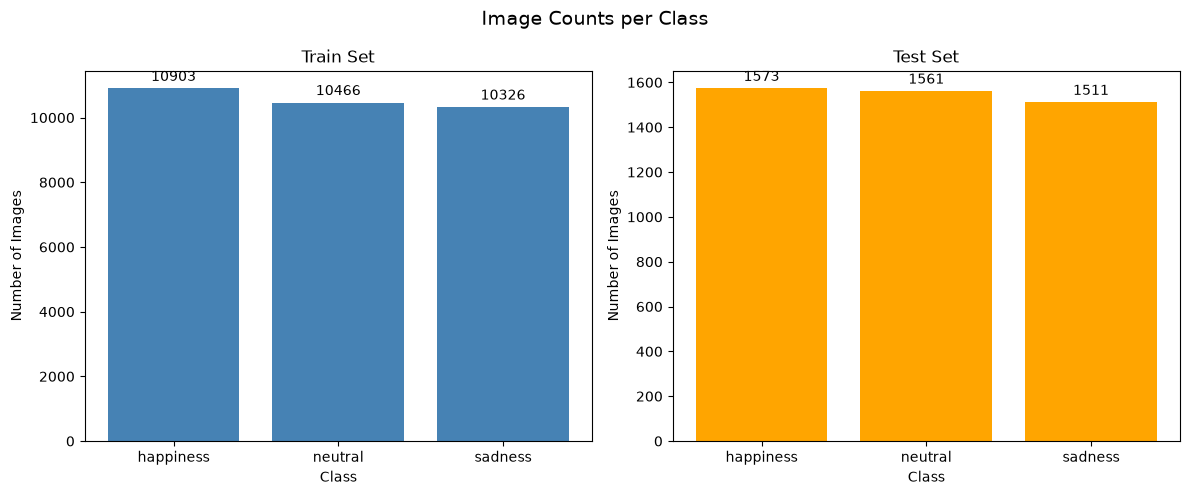

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Class names and counts
classes = ['happiness', 'neutral', 'sadness']
train_counts = [10903, 10466, 10326]
test_counts = [1573, 1561, 1511]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Train chart
bars1 = ax1.bar(classes, train_counts, color='steelblue')
ax1.set_title('Train Set')
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Images')
ax1.bar_label(bars1, padding=3)

# Test chart
bars2 = ax2.bar(classes, test_counts, color='orange')
ax2.set_title('Test Set')
ax2.set_xlabel('Class')
ax2.set_ylabel('Number of Images')
ax2.bar_label(bars2, padding=3)

plt.suptitle('Image Counts per Class', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
import os
from PIL import Image

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed"

corrupt_files = []
sizes = set()
modes = set()

# Check every image for corruption, size and mode
for split in ['train', 'test']:
    split_path = os.path.join(processed_path, split)
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path)
                img.verify()        # Check if corrupt
                img = Image.open(img_path)  # Reopen after verify
                sizes.add(img.size)
                modes.add(img.mode)
            except Exception as e:
                corrupt_files.append(img_path)

print(f"Total corrupt files: {len(corrupt_files)}")
print(f"Unique sizes found: {sizes}")
print(f"Unique modes found: {modes}")

Total corrupt files: 0
Unique sizes found: {(100, 100), (48, 48)}
Unique modes found: {'RGB', 'L'}


In [6]:
import os
from PIL import Image

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed"

corrupt_files = []

# Find and remove corrupt images
for split in ['train', 'test']:
    split_path = os.path.join(processed_path, split)
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = Image.open(img_path)
                img.verify()
            except Exception:
                corrupt_files.append(img_path)
                os.remove(img_path)  # Delete corrupt image

print(f"Deleted {len(corrupt_files)} corrupt files")
print("Cleaning complete!")

Deleted 0 corrupt files
Cleaning complete!


In [7]:
import os
import hashlib
from PIL import Image

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed"

def get_image_hash(img_path):
    # Generate hash of image content
    with open(img_path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

seen_hashes = {}
duplicate_files = []

# Find duplicate images using hash comparison
for split in ['train', 'test']:
    split_path = os.path.join(processed_path, split)
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img_hash = get_image_hash(img_path)
            if img_hash in seen_hashes:
                duplicate_files.append(img_path)
                os.remove(img_path)  # Remove duplicate
            else:
                seen_hashes[img_hash] = img_path

print(f"Deleted {len(duplicate_files)} duplicate images")

Deleted 617 duplicate images


In [8]:
import os
import cv2

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed"

# Blur threshold - images below this value are considered blurry
BLUR_THRESHOLD = 10.0

blur_removed = 0

# Find and remove blurry images
for split in ['train', 'test']:
    split_path = os.path.join(processed_path, split)
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            # Calculate blur score using Laplacian variance
            blur_score = cv2.Laplacian(img, cv2.CV_64F).var()
            if blur_score < BLUR_THRESHOLD:
                os.remove(img_path)
                blur_removed += 1

print(f"Deleted {blur_removed} blurry images")
print("Cleaning complete!")

Deleted 30 blurry images
Cleaning complete!


--- TRAIN (after cleaning) ---
happiness: 10801 images
neutral: 10315 images
sadness: 10097 images

--- TEST (after cleaning) ---
happiness: 1540 images
neutral: 1516 images
sadness: 1424 images


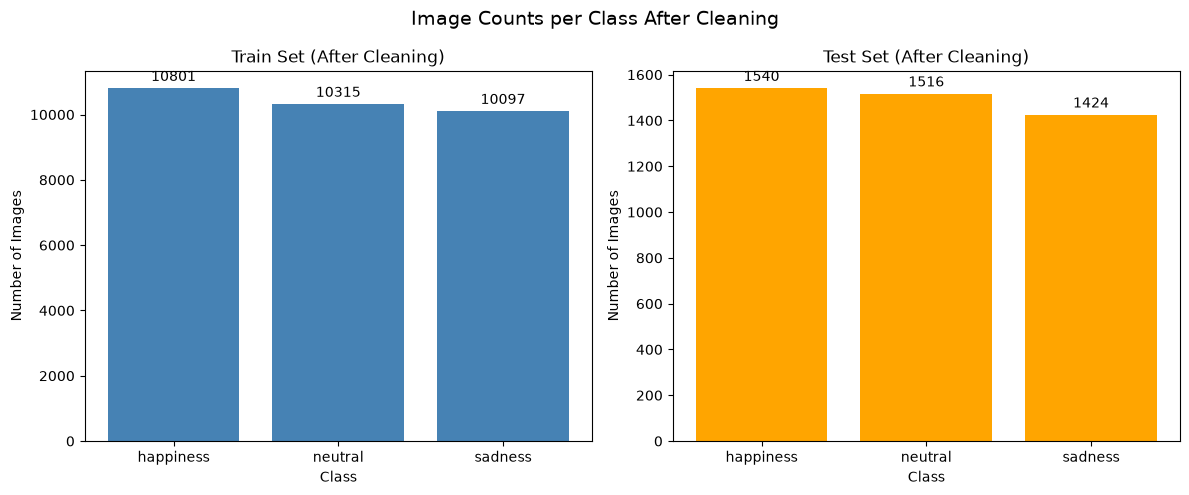

In [9]:
import os
import matplotlib.pyplot as plt
import numpy as np

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed"

train_counts = []
test_counts = []
classes = ['happiness', 'neutral', 'sadness']

# Count remaining images after cleaning
for class_name in classes:
    train_class_path = os.path.join(processed_path, 'train', class_name)
    test_class_path = os.path.join(processed_path, 'test', class_name)
    train_counts.append(len(os.listdir(train_class_path)))
    test_counts.append(len(os.listdir(test_class_path)))

# Print counts
print("--- TRAIN (after cleaning) ---")
for c, count in zip(classes, train_counts):
    print(f"{c}: {count} images")

print("\n--- TEST (after cleaning) ---")
for c, count in zip(classes, test_counts):
    print(f"{c}: {count} images")

# Plot side by side bar charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

bars1 = ax1.bar(classes, train_counts, color='steelblue')
ax1.set_title('Train Set (After Cleaning)')
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Images')
ax1.bar_label(bars1, padding=3)

bars2 = ax2.bar(classes, test_counts, color='orange')
ax2.set_title('Test Set (After Cleaning)')
ax2.set_xlabel('Class')
ax2.set_ylabel('Number of Images')
ax2.bar_label(bars2, padding=3)

plt.suptitle('Image Counts per Class After Cleaning', fontsize=14)
plt.tight_layout()
plt.show()

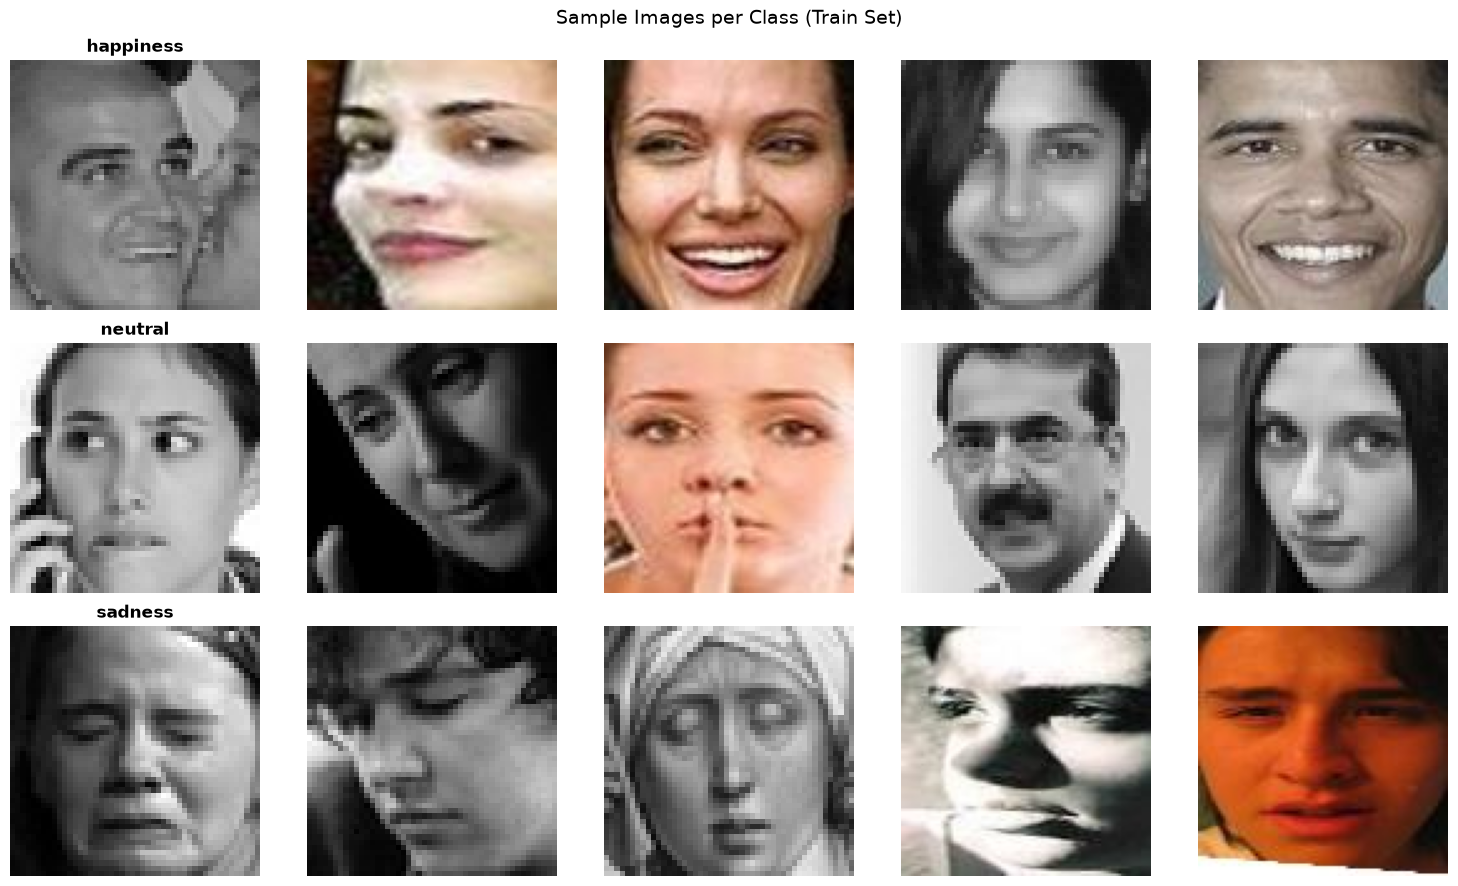

In [10]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random

processed_path = r"C:\Users\Bushra Shahid\Desktop\IDVS\FER Model\Data\processed"

classes = ['happiness', 'neutral', 'sadness']

fig, axes = plt.subplots(3, 5, figsize=(15, 9))

# Show 5 random sample images from each class
for row, class_name in enumerate(classes):
    class_path = os.path.join(processed_path, 'train', class_name)
    images = random.sample(os.listdir(class_path), 5)
    
    for col, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        axes[row, col].imshow(img, cmap='gray' if img.mode == 'L' else None)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(class_name, fontsize=12, fontweight='bold')

plt.suptitle('Sample Images per Class (Train Set)', fontsize=14)
plt.tight_layout()
plt.show()